<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_71_knn_on_breast_cancer_dataset/Lecture_71_knn_on_breast_cancer_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing the necessary libraries
import numpy as np
import pandas as pd

In [ ]:
# Loading the dataset
df = pd.read_csv('/content/data.csv')

In [ ]:
# Displaying the first 5 rows of the dataframe
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# Dropping the 'id' and 'Unnamed: 32' columns
df.drop(columns=['id','Unnamed: 32'],inplace=True)
# Displaying the first 5 rows of the dataframe after dropping the columns
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Displaying the shape of the dataframe
df.shape

(569, 31)

In [ ]:
# Importing the train_test_split function from the sklearn.model_selection module
from re import X
from sklearn.model_selection import train_test_split

In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0], test_size=0.2, random_state=2)

In [ ]:
# Displaying the first 5 rows of the training data
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
560,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,0.1537,0.06171,...,15.30,33.17,100.20,706.7,0.1241,0.22640,0.1326,0.10480,0.2250,0.08321
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,11.68,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083
198,19.18,22.49,127.50,1148.0,0.08523,0.14280,0.11140,0.06772,0.1767,0.05529,...,23.36,32.06,166.40,1688.0,0.1322,0.56010,0.3865,0.17080,0.3193,0.09221
203,13.81,23.75,91.56,597.8,0.13230,0.17680,0.15580,0.09176,0.2251,0.07421,...,19.20,41.85,128.50,1153.0,0.2226,0.52090,0.4646,0.20130,0.4432,0.10860
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,...,12.84,35.34,87.22,514.0,0.1909,0.26980,0.4023,0.14240,0.2964,0.09606


In [ ]:
# Displaying the shape of the training data
X_train.shape

(455, 30)

In [ ]:
# Importing the StandardScaler from the sklearn.preprocessing module
from sklearn.preprocessing import StandardScaler

# Creating a StandardScaler object
scaler = StandardScaler()

# Fitting the scaler to the training data and transforming it
X_train = scaler.fit_transform(X_train)
# Transforming the testing data
X_test = scaler.transform(X_test)

In [ ]:
# Displaying the scaled training data
X_train

array([[-0.01330339,  1.7757658 , -0.01491962, ..., -0.13236958,
        -1.08014517, -0.03527943],
       [-0.8448276 , -0.6284278 , -0.87702746, ..., -1.11552632,
        -0.85773964, -0.72098905],
       [ 1.44755936,  0.71180168,  1.47428816, ...,  0.87583964,
         0.4967602 ,  0.46321706],
       ...,
       [-0.46608541, -1.49375484, -0.53234924, ..., -1.32388956,
        -1.02997851, -0.75145272],
       [-0.50025764, -1.62161319, -0.527814  , ..., -0.0987626 ,
         0.35796577, -0.43906159],
       [ 0.96060511,  1.21181916,  1.00427242, ...,  0.8956983 ,
        -1.23064515,  0.50697397]])

In [ ]:
# Displaying the shape of the scaled training data
X_train.shape

(455, 30)

In [ ]:
# Importing the KNeighborsClassifier from the sklearn.neighbors module
from sklearn.neighbors import KNeighborsClassifier

# Creating a KNeighborsClassifier object with 3 neighbors
Knn = KNeighborsClassifier(n_neighbors=3)
# Fitting the model to the training data
Knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Importing the accuracy_score function from the sklearn.metrics module
from sklearn.metrics import accuracy_score

# Making predictions on the testing data
y_pred = Knn.predict(X_test)
# Calculating the accuracy of the model
accuracy_score(y_test,y_pred)

0.9912280701754386

In [ ]:
# Create an empty list to store the scores
scores = []

# Loop through a range of k values from 1 to 15
for i in range(1,16):

  # Create a KNeighborsClassifier object with the current k value
  Knn = KNeighborsClassifier(n_neighbors=i)

  # Fit the model to the training data
  Knn.fit(X_train,y_train)

  # Make predictions on the testing data
  y_pred = Knn.predict(X_test)

  # Calculate the accuracy of the model and append it to the scores list
  scores.append(accuracy_score(y_test,y_pred))

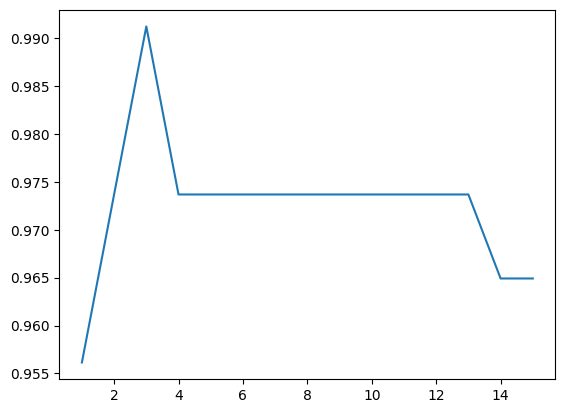

In [ ]:
# Import the matplotlib.pyplot library for plotting
import matplotlib.pyplot as plt

# Plot the scores against the range of k values
plt.plot(range(1, 16), scores)

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, fixed

# Function to load the breast cancer dataset
def load_data():
    cancer = datasets.load_breast_cancer()
    return cancer

# Function to plot the decision boundaries for a given number of neighbors
def plot_decision_boundaries(n_neighbors, data, labels):
    # Set the step size for the meshgrid
    h = .02
    # Create color maps for the plot
    cmap_light = ListedColormap(['orange', 'blue'])
    cmap_bold = ListedColormap(['darkorange', 'darkblue'])

    # Create a KNeighborsClassifier object with the given number of neighbors
    clf = neighbors.KNeighborsClassifier(n_neighbors)
    # Fit the model to the data
    clf.fit(data, labels)

    # Create a meshgrid of points to plot the decision boundaries
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predict the class for each point in the meshgrid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Reshape the predictions to match the meshgrid shape
    Z = Z.reshape(xx.shape)
    # Create a new figure with a specific size
    plt.figure(figsize=(8, 6))
    # Plot the decision boundaries
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot the data points
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    # Set the x and y axis limits
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    # Set the title of the plot
    plt.title(f'2-Class classification (k = {n_neighbors})')
    # Show the plot
    plt.show()

# Load the breast cancer dataset
cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Create an interactive widget to allow the user to change the number of neighbors
interact(plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X), labels=fixed(y));

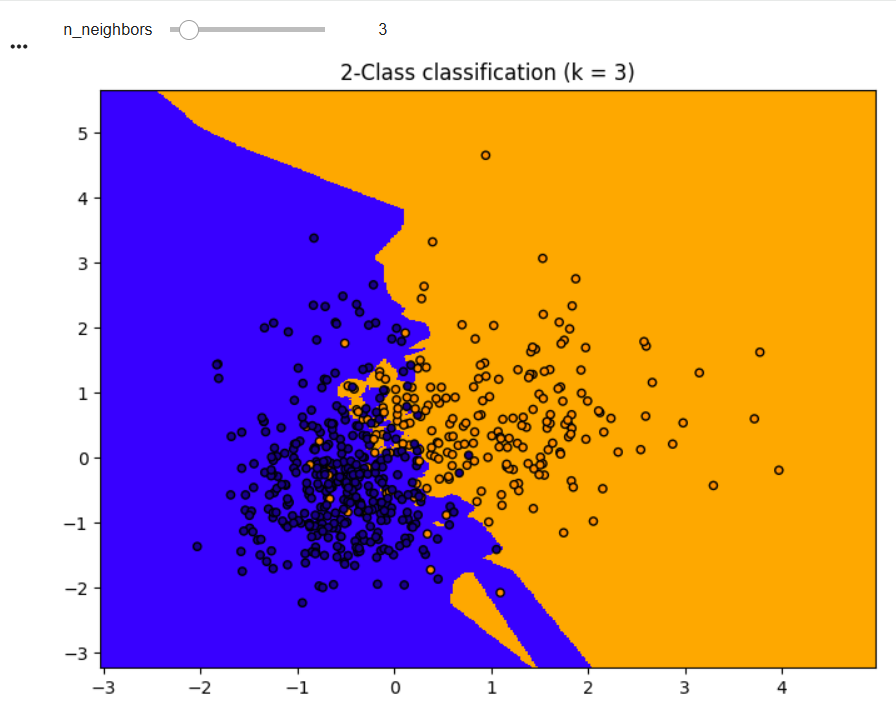